# 06 — Model Training & Evaluation (XGBoost, PV1 and PV2 separately)

**Goal:** predict `PV1_Power_W` and `PV2_Power_W` independently, using XGBoost for both.

**Input:** `../Output/checkpoint_05_final.pkl`


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

OUTPUT_DIR = "../Output"
df = pd.read_pickle(f"{OUTPUT_DIR}/checkpoint_05_final.pkl")
print(df.shape)


(5832, 30)


In [2]:
df.columns

Index(['Timestamp', 'PV1_Current_A', 'PV2_Current_A', 'PV1_Voltage_V',
       'PV2_Voltage_V', 'PV1_Power_W', 'PV2_Power_W', 'PV_Total_Power_W',
       'Solar_Radiation_Wm2', 'Outdoor_Temp_C', 'Dew_Point_C', 'Wind_Speed_ms',
       'Wind_Dir_deg', 'Pressure_hPa', 'Humidity_pct', 'UV_Index',
       'Wind_Gust_ms', 'Rain_mm', 'AQI_US', 'PM25_ugm3', 'PM10_ugm3',
       'PM1_ugm3', 'Indoor_Temp_C', 'Indoor_Humidity_pct',
       'Indoor_Pressure_Pa', 'PV_imputed', 'hour', 'month', 'day_of_year',
       'is_daylight'],
      dtype='str')

## 1. Build a leakage-free feature set

All electrical readings — for both panels, and the combined total — are excluded from the
features. These are outputs measured at the same instant as power itself, not things you'd
know in advance in a real forecasting scenario.

Redundant weather columns identified during the correlation analysis are also dropped
(`UV_Index` ≈ `Solar_Radiation_Wm2`, indoor sensors ≈ outdoor equivalents, `AQI_US`/`PM10`/`PM1`
≈ `PM25`, `Wind_Gust_ms` ≈ `Wind_Speed_ms`).


In [3]:
electrical_cols = ["PV1_Power_W", "PV2_Power_W", "PV_Total_Power_W",
                   "PV1_Current_A", "PV2_Current_A", "PV1_Voltage_V", "PV2_Voltage_V"]

redundant_cols = ["UV_Index", "Indoor_Temp_C", "Indoor_Humidity_pct", "Indoor_Pressure_Pa",
                  "AQI_US", "PM10_ugm3", "PM1_ugm3", "Wind_Gust_ms"]

targets = ["PV1_Power_W", "PV2_Power_W"]
drop_cols = electrical_cols + redundant_cols + ["Timestamp", "PV_imputed"]

feature_cols = [c for c in df.columns if c not in drop_cols]
print("Base features:", feature_cols)


Base features: ['Solar_Radiation_Wm2', 'Outdoor_Temp_C', 'Dew_Point_C', 'Wind_Speed_ms', 'Wind_Dir_deg', 'Pressure_hPa', 'Humidity_pct', 'Rain_mm', 'PM25_ugm3', 'hour', 'month', 'day_of_year', 'is_daylight']


### Cyclical encoding for hour and day-of-year

In [4]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

feature_cols = [c for c in feature_cols if c not in ["hour", "day_of_year", "month"]] + \
               ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]
print(f"Final feature count: {len(feature_cols)}")
print(feature_cols)


Final feature count: 14
['Solar_Radiation_Wm2', 'Outdoor_Temp_C', 'Dew_Point_C', 'Wind_Speed_ms', 'Wind_Dir_deg', 'Pressure_hPa', 'Humidity_pct', 'Rain_mm', 'PM25_ugm3', 'is_daylight', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## 2. Chronological train/test split

Held-out period is the most recent ~20% of the timeline — not a random split, since adjacent
hours are correlated and a random shuffle would overstate accuracy.

In [5]:
df = df.sort_values("Timestamp").reset_index(drop=True)

split_date = df["Timestamp"].quantile(0.8)
train_df = df[df["Timestamp"] < split_date]
test_df = df[df["Timestamp"] >= split_date]

print(f"Train: {train_df['Timestamp'].min()} to {train_df['Timestamp'].max()}  ({len(train_df)} rows)")
print(f"Test:  {test_df['Timestamp'].min()} to {test_df['Timestamp'].max()}  ({len(test_df)} rows)")

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]


Train: 2026-01-01 00:00:00 to 2026-07-14 08:00:00  (4665 rows)
Test:  2026-07-14 09:00:00 to 2026-08-31 23:00:00  (1167 rows)


## 3. Train one XGBoost model per panel

In [6]:
models = {}
predictions = {}
results = {}

xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

for target in targets:
    y_train = train_df[target]
    y_test = test_df[target]

    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    preds = np.clip(model.predict(X_test), 0, None)

    models[target] = model
    predictions[target] = preds
    results[target] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    }

print("Full test set:")
pd.DataFrame(results).T


Full test set:


,MAE,RMSE,R2
PV1_Power_W,8.774819,18.745919,0.978653
PV2_Power_W,7.972388,17.729962,0.979021


## 4. Daylight-only evaluation

Nighttime hours are trivial to predict (power ≈ 0), so they inflate the full-set score.
This is the metric that reflects real forecasting accuracy.

In [7]:
daylight_mask = test_df["is_daylight"] == 1
daylight_results = {}

for target in targets:
    y_test_daylight = test_df.loc[daylight_mask, target]
    preds_daylight = predictions[target][daylight_mask.values]
    daylight_results[target] = {
        "MAE": mean_absolute_error(y_test_daylight, preds_daylight),
        "RMSE": np.sqrt(mean_squared_error(y_test_daylight, preds_daylight)),
        "R2": r2_score(y_test_daylight, preds_daylight),
    }

daylight_results_df = pd.DataFrame(daylight_results).T
daylight_results_df


,MAE,RMSE,R2
PV1_Power_W,13.744954,23.690742,0.966337
PV2_Power_W,12.435467,22.402353,0.966099


## 5. Predictions vs. actual — both panels

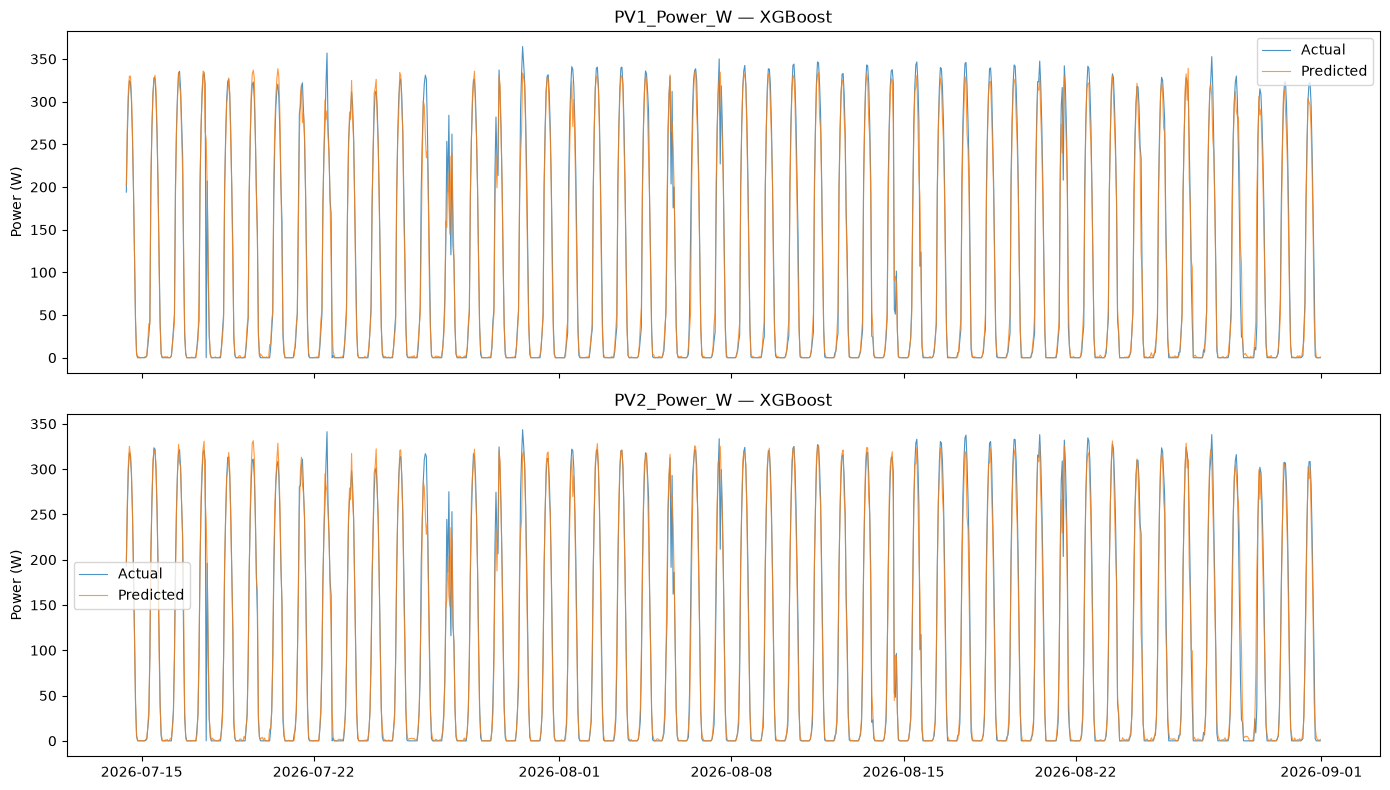

In [8]:
fig, axes = plt.subplots(len(targets), 1, figsize=(14, 4 * len(targets)), sharex=True)

for ax, target in zip(axes, targets):
    ax.plot(test_df["Timestamp"], test_df[target].values, label="Actual", linewidth=0.8, alpha=0.8)
    ax.plot(test_df["Timestamp"], predictions[target], label="Predicted", linewidth=0.8, alpha=0.8)
    ax.set_title(f"{target} — XGBoost")
    ax.set_ylabel("Power (W)")
    ax.legend()

plt.tight_layout()
plt.show()


## 6. Do PV1 and PV2 behave the same, or differently?

If both panels see identical conditions, their models should perform almost identically.
A persistent gap here points to something panel-specific (shading, soiling, wiring,
orientation) rather than a modeling issue.

In [9]:
print(daylight_results_df[["RMSE"]])
print(f"\nDifference (PV1 - PV2) RMSE: {daylight_results_df.loc['PV1_Power_W','RMSE'] - daylight_results_df.loc['PV2_Power_W','RMSE']:.2f} W")


                  RMSE
PV1_Power_W  23.690742
PV2_Power_W  22.402353

Difference (PV1 - PV2) RMSE: 1.29 W


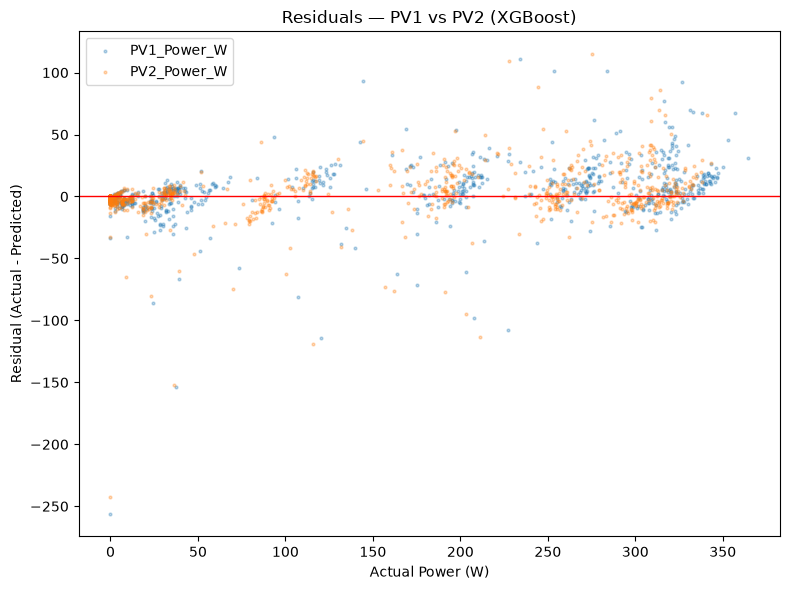

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for target in targets:
    residuals = test_df[target].values - predictions[target]
    ax.scatter(test_df[target].values, residuals, s=4, alpha=0.3, label=target)

ax.axhline(0, color="red", linewidth=1)
ax.set_xlabel("Actual Power (W)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residuals — PV1 vs PV2 (XGBoost)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Save models

In [11]:
import joblib
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

for target in targets:
    joblib.dump(models[target], f"{OUTPUT_DIR}/xgb_{target}.joblib")

joblib.dump(feature_cols, f"{OUTPUT_DIR}/feature_cols.joblib")
print("Saved models and feature list to", OUTPUT_DIR)


Saved models and feature list to Output


## Summary

- One XGBoost model trained per panel, both using the same leakage-free weather/time feature set.
- Evaluated on a chronological holdout (last ~20% of the timeline), with metrics reported both
  on the full test set and daylight-only (the more meaningful number).
- Section 6 compares the two panels directly — a persistent RMSE gap between them is a
  physical signal worth investigating (shading, soiling, degradation), not just noise.

**Next steps:** hyperparameter tuning via `GridSearchCV`/`RandomizedSearchCV` with a
`TimeSeriesSplit` cross-validator (not a regular k-fold), and re-evaluating once more months
of data are available to cover the missing autumn/winter seasons.
